# Football Analytics Package — Demo Notebook

This notebook demonstrates the full capabilities of the `football-analytics` package.

We use two data sources:
- **StatsBomb open data** — player-level event data, xG, passes, defensive actions
- **football-data.org** — standings, fixtures, match results

### Sections
1. Setup and imports
2. Exploring available StatsBomb data
3. Match level analysis
4. Player comparison — key players across La Liga seasons
5. Season level analysis and comparison

### 1. Setup and imports 

In [ ]:
# standard library
import warnings

import matplotlib.pyplot as plt

# data
import pandas as pd

from football_analytics.utils.exceptions import DataNotFoundError

warnings.filterwarnings("ignore")

# our package — data layer
from football_analytics.data import FootballDataClient, StatsBombClient  # noqa: E402, I001

# our package — analytics layer
from football_analytics.analytics import (  # noqa: E402
    # form
    get_recent_form,
    get_points_per_game,
    get_home_away_split,
    # xG
    get_match_xg_summary,
    get_player_xg_ranking,
    get_xg_overperformance,  #TODO: add cell demonstrating get_xg_overperformance
    # standings
    get_clean_standings,
    get_expected_vs_actual,
    # player
    get_top_performers,
    add_per_90_columns,
    per_90,
)



print("imports OK")

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


imports OK


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Initialise clients 

# StatsBomb requires no API key 
sb_client = StatsBombClient()

# FootballDataClient reads the key from .env aautomatically 
fd_client = FootballDataClient()

print("Clients initialised OK")

Clients initialised OK


### 2. Exploring available StatsBomb 

First we can look at what data from which competitions are contained in the open package of StatsBomb.

In [5]:
competitions = sb_client.get_competitions()
competitions

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
75,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2026-04-11T12:48:10.012987,2021-06-13T16:17:31.694,NaN,2026-04-11T12:48:10.012987
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507
77,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2026-05-05T03:03:04.199896,2026-05-05T03:05:32.480837,2026-05-05T03:05:32.480837,2026-05-05T03:03:04.199896
78,72,107,International,Women's World Cup,female,False,True,2023,2026-05-03T13:51:31.021141,2026-05-03T13:55:52.303219,2026-05-03T13:55:52.303219,2026-05-03T13:51:31.021141


In [6]:
# Let's see all the available competitions  
competitions.competition_name.unique()

<StringArray>
[          '1. Bundesliga',  'African Cup of Nations',
        'Champions League',            'Copa America',
            'Copa del Rey', 'FA Women's Super League',
      'FIFA U20 World Cup',          'FIFA World Cup',
       'Frauen Bundesliga',     'Indian Super league',
                 'La Liga',                  'Liga F',
        'Liga Profesional',                 'Ligue 1',
     'Major League Soccer',   'North American League',
                    'NWSL',          'Premier League',
                 'Serie A',           'Serie A Women',
               'UEFA Euro',      'UEFA Europa League',
       'UEFA Women's Euro',       'Women's World Cup']
Length: 24, dtype: str

In [7]:
# As a domain knowledge, we're aware that open StatsBomb data contains
# a lot of La Liga data.  Below is shown all the available seasons for LaLiga
 
bundesliga = competitions[
    competitions["competition_name"].str.contains("liga", case=False)
]
print(bundesliga[["competition_id", "season_id", "competition_name", "season_name"]])


    competition_id  season_id   competition_name season_name
0                9        281      1. Bundesliga   2023/2024
1                9         27      1. Bundesliga   2015/2016
38             135        281  Frauen Bundesliga   2023/2024
40              11         90            La Liga   2020/2021
41              11         42            La Liga   2019/2020
42              11          4            La Liga   2018/2019
43              11          1            La Liga   2017/2018
44              11          2            La Liga   2016/2017
45              11         27            La Liga   2015/2016
46              11         26            La Liga   2014/2015
47              11         25            La Liga   2013/2014
48              11         24            La Liga   2012/2013
49              11         23            La Liga   2011/2012
50              11         22            La Liga   2010/2011
51              11         21            La Liga   2009/2010
52              11      

### 3. Match Level Analysis 

We start our data exploration from the smallest possible unit of comparison for our package, and that is a single match. Here we demonstrate which match-level analyses can be done with the package. 

We use a match from La Liga season 2015/16 (competition_id=11, season_id=27).

In [ ]:
# retrieving all the matches in the given season 
COMPETITION_ID = 11 
SEASON_ID = 27 # 2015/16 

laliga_matches_15 = sb_client.get_matches(competition_id=COMPETITION_ID,
                                        season_id=SEASON_ID)

print ( f"Total matches in 2015/16: {len(laliga_matches_15)}")
laliga_matches_15[["match_id", "home_team", "away_team", "home_score", "away_score"]].head(10)

Total matches in 2015/16: 380


,match_id,home_team,away_team,home_score,away_score
0,3825739,Real Madrid,Sporting Gijón,5,1
1,3825848,Levante UD,Eibar,2,2
2,3825895,Las Palmas,Sevilla,2,0
3,3825894,RC Deportivo La Coruña,Getafe,0,2
4,3825855,Málaga,Levante UD,3,1
5,3825908,Espanyol,Eibar,4,2
6,3825883,Málaga,Las Palmas,4,1
7,3825900,Sporting Gijón,Villarreal,2,0
8,3825902,Rayo Vallecano,Levante UD,3,1
9,3825876,Real Betis,Getafe,2,1


In [9]:
# picking one match to explore from Barcelona matches 

barca_matches = sb_client.get_matches(competition_id=COMPETITION_ID,
                                      season_id=SEASON_ID,
                                      team="Barcelona")

print(f"Barcelona matches available: expected -> 38 retrieved -> {len(barca_matches)}")
barca_matches[["match_id", "home_team", "away_team", "home_score", "away_score"]].head(10)

Barcelona matches available: expected -> 38 retrieved -> 38


,match_id,home_team,away_team,home_score,away_score
358,266236,Athletic Club,Barcelona,0,1
357,267422,Barcelona,Málaga,1,0
371,266166,Atlético Madrid,Barcelona,1,2
377,266490,Barcelona,Levante UD,4,1
375,266467,Celta Vigo,Barcelona,4,1
356,267611,Barcelona,Las Palmas,2,1
306,3825617,Sevilla,Barcelona,2,1
300,3825627,Barcelona,Rayo Vallecano,5,2
186,3825637,Barcelona,Eibar,3,1
288,3825645,Getafe,Barcelona,0,2


#### 3.1 xG Summary for a Single Match 

`get_shots()` returns the raw shot data for a match.

`get_match_xg_summary()` takes raw shot data and returns a team-level summary of total shots, shots on target, xG and goals. 

xg_difference tells us how much a team over or underperformed their chances. 

In [10]:
# use the Barca-Rayo Vallecano match because it has a very high score and probably a lot
# of data to showcase 
MATCH_ID = barca_matches.iloc[3]["match_id"]
home = barca_matches.iloc[3]["home_team"]
away = barca_matches.iloc[3]["away_team"]
home_score = barca_matches.iloc[3]["home_score"]
away_score = barca_matches.iloc[3]["away_score"]

print(f"Match: {home} {home_score} - {away_score} {away}\n")

shots = sb_client.get_shots(match_id=MATCH_ID)
xg_summary = get_match_xg_summary(shots)
xg_summary

Match: Barcelona 4 - 1 Levante UD



,team,total_shots,shots_on_target,total_xg,goals,xg_difference
0,Barcelona,20,7,3.530,4,0.470
1,Levante UD,11,4,0.721,1,0.279


#### 3.2 Player Shooting Stats for a Single Match 

`get_player_shooting_match()` retruns player level xG data for a single match with data on shots taken, shots on target, goals scored and xG generated

In [11]:
shooting_stats = sb_client.get_player_shooting_match(match_id=MATCH_ID)
shooting_stats.sort_values('total_xg', ascending=False)


,player,team,position,shots,shots_on_target,goals,total_xg,xg_per_shot
5,Lionel Andrés Messi Cuccittini,Barcelona,Center Attacking Midfield,10,4,2,2.150,0.215
9,Neymar da Silva Santos Junior,Barcelona,Left Wing,4,1,1,0.561,0.140
6,Marc Bartra Aregall,Barcelona,Right Center Back,2,1,1,0.403,0.202
7,Munir El Haddadi Mohamed,Barcelona,Right Wing,2,1,0,0.280,0.140
13,Víctor Casadesús Castaño,Levante UD,Right Center Forward,1,1,1,0.180,0.180
3,Jefferson Andrés Lerma Solís,Levante UD,Left Center Midfield,2,0,0,0.162,0.081
12,Víctor Camarasa Ferrando,Levante UD,Right Center Midfield,2,0,0,0.161,0.081
11,Sandro Ramírez Castillo,Barcelona,Center Forward,1,0,0,0.116,0.116
8,Nabil Ghilas,Levante UD,Right Center Forward,1,0,0,0.098,0.098
0,Antonio García Aranda,Levante UD,Left Wing Back,1,0,0,0.045,0.045


#### 3.3 Player Goals & Assists for a Single Match 

`get_player_goals_assists_match()` returns the goals and assists for a single match

In [12]:
goals_assists = sb_client.get_player_goals_assists_match(match_id=MATCH_ID)
goals_assists.sort_values('goals',ascending=False)

,player,team,position,goals,assists
1,Lionel Andrés Messi Cuccittini,Barcelona,Center Attacking Midfield,2,1
3,Neymar da Silva Santos Junior,Barcelona,Left Wing,1,0
2,Marc Bartra Aregall,Barcelona,Right Center Back,1,1
4,Víctor Casadesús Castaño,Levante UD,Right Center Forward,1,0
0,Antonio García Aranda,Levante UD,Left Wing Back,0,1


#### 3.4 Player xG Ranking for a Single Match 

`get_player_xg_ranking()` ranks every player by their total xG generated
in the match. Useful for identifying who created the best chances regardless
of whether they scored.

In [13]:
xg_ranking = get_player_xg_ranking(shots)
xg_ranking

,player,team,shots,goals,total_xg,xg_per_shot
0,Lionel Andrés Messi Cuccittini,Barcelona,10,2,2.150,0.215
1,Neymar da Silva Santos Junior,Barcelona,4,1,0.561,0.140
2,Marc Bartra Aregall,Barcelona,2,1,0.403,0.202
3,Munir El Haddadi Mohamed,Barcelona,2,0,0.280,0.140
4,Víctor Casadesús Castaño,Levante UD,1,1,0.180,0.180
5,Jefferson Andrés Lerma Solís,Levante UD,2,0,0.162,0.081
6,Víctor Camarasa Ferrando,Levante UD,2,0,0.161,0.081
7,Sandro Ramírez Castillo,Barcelona,1,0,0.116,0.116
8,Nabil Ghilas,Levante UD,1,0,0.098,0.098
9,Antonio García Aranda,Levante UD,1,0,0.045,0.045


#### 3.5 Player Passing Stats for a Single Match 

`get_player_passing_match()` returns total passes, completed passes, completion rates and progressive passes per player for a single match. 

In [14]:
passing = sb_client.get_player_passing_match(match_id=MATCH_ID)
passing.sort_values('passes', ascending=False).head(10)

,player,team,position,passes,passes_completed,completion_rate,progressive_passes
2,Daniel Alves da Silva,Barcelona,Right Back,121,105,86.8,0
5,Ivan Rakitić,Barcelona,Right Defensive Midfield,89,81,91.0,0
12,Marc Bartra Aregall,Barcelona,Right Center Back,75,66,88.0,0
0,Adriano Correia Claro,Barcelona,Left Back,74,66,89.2,0
7,Javier Alejandro Mascherano,Barcelona,Left Center Back,73,72,98.6,0
16,Neymar da Silva Santos Junior,Barcelona,Left Wing,63,42,66.7,0
11,Lionel Andrés Messi Cuccittini,Barcelona,Center Attacking Midfield,61,49,80.3,0
14,Munir El Haddadi Mohamed,Barcelona,Right Wing,52,45,86.5,0
9,José Antonio García Rabasco,Levante UD,Center Defensive Midfield,51,38,74.5,0
21,Sergio Busquets i Burgos,Barcelona,Left Defensive Midfield,41,40,97.6,0


#### 3.6 Player Defensive Stats for a Single Match 

`get_player_defensive_match()` returns tackles, interceptions and clearances per player. This method allows us to see the defensive contributions from each player

In [15]:
defensive = sb_client.get_player_defensive_match(match_id=MATCH_ID)

defensive.sort_values('interceptions',ascending=False).head(10)

,player,team,position,tackles,interceptions,clearances
9,Juan Francisco García García,Levante UD,Left Center Back,0,4,5
3,Deyverson Brum Silva Acosta,Levante UD,Left Center Forward,0,3,0
15,Víctor Camarasa Ferrando,Levante UD,Right Center Midfield,0,3,0
7,Jefferson Andrés Lerma Solís,Levante UD,Left Center Midfield,0,2,0
10,Marc Bartra Aregall,Barcelona,Right Center Back,0,1,4
2,Daniel Alves da Silva,Barcelona,Right Back,0,1,1
11,Munir El Haddadi Mohamed,Barcelona,Right Wing,0,1,0
6,Iván López Mendoza,Levante UD,Right Wing Back,0,1,4
5,Ivan Rakitić,Barcelona,Right Defensive Midfield,0,1,0
8,José Antonio García Rabasco,Levante UD,Center Defensive Midfield,0,1,0


### 4. Season Level Analysis 

With this package, we can go even deeper into player analysis by being able to compare statistics of multiple players across a different leagues for a complete season.   

The open version of StatsBomb python package has the most complete 2015/16 season data for La Liga and Premier League. Here we compare three key players across three positions: 
- **Forwards:** Messi, Suárez, Ronaldo
- **Midfielders:** Modrić, Busquets, Andres Iniesta
- **Defenders:** Mascherano, Ramos, Godín

It's important to use the exact name strings of players from StatsBomb. I collected the full names from a web search, however this presents a point of possible improvement in user experience for the future. The full name strings for players are defined below.

Below are the full StatsBomb names for the players we chose 

- *Forwards:* Lionel Andrés Messi Cuccittini,  Luis Alberto Suárez Díaz, Cristiano Ronaldo dos Santos Aveiro

- *Midfielders:* Luka Modrić, Sergio Busquets i Burgos, Andrés Iniesta Luján

- *Defenders:* Sergio Ramos García, Javier Alejandro Mascherano, Diego Roberto Godín Leal

#### 4.1 Defining Player and Season IDs for Comparison

In [16]:
# exact names as they appear in StatsBomb data
FORWARDS = [
    "Lionel Andrés Messi Cuccittini",
    "Luis Alberto Suárez Díaz",
    "Cristiano Ronaldo dos Santos Aveiro",
]

MIDFIELDERS = [
    "Luka Modrić",
    "Sergio Busquets i Burgos",
    "Andrés Iniesta Luján",
]

DEFENDERS = [
    "Sergio Ramos García",
    "Javier Alejandro Mascherano",
    "Diego Roberto Godín Leal",
]

# display labels for cleaner output
PLAYER_LABELS = {
    "Lionel Andrés Messi Cuccittini": "Messi",
    "Luis Alberto Suárez Díaz": "Suárez",
    "Cristiano Ronaldo dos Santos Aveiro": "Ronaldo",
    "Luka Modrić": "Modrić",
    "Sergio Busquets i Burgos": "Busquets",
    "Andrés Iniesta Luján": "Iniesta",
    "Sergio Ramos García": "Ramos",
    "Javier Alejandro Mascherano": "Mascherano",
    "Diego Roberto Godín Leal": "Godín",
}

# La Liga seasons we have full data for — season_id: label
SEASONS = {
    27: "2015/16",

}

COMPETITION_ID = 11

print("Players and seasons defined.")
print(f"Forwards:    {[PLAYER_LABELS[p] for p in FORWARDS]}")
print(f"Midfielders: {[PLAYER_LABELS[p] for p in MIDFIELDERS]}")
print(f"Defenders:   {[PLAYER_LABELS[p] for p in DEFENDERS]}")

Players and seasons defined.
Forwards:    ['Messi', 'Suárez', 'Ronaldo']
Midfielders: ['Modrić', 'Busquets', 'Iniesta']
Defenders:   ['Ramos', 'Mascherano', 'Godín']


#### 4.2 Forward Player Comparisons

With the use of StatsBombClient we will compare the shooting, passing, goal and assist stats between forward players 

In [ ]:
forward_shooting = sb_client.get_player_shooting_season(
    competition_id=COMPETITION_ID,
    season_ids=SEASON_ID,
    players=FORWARDS,
)
forward_shooting["player"] = forward_shooting["player"].map(PLAYER_LABELS)
forward_shooting.sort_values(["season_id", "total_xg"], ascending=[True, False])

,player,team,season_id,season_name,matches_played,position,shots,shots_on_target,goals,total_xg,xg_per_shot
0,Ronaldo,Real Madrid,27,2015/2016,36,Left Wing,228,96,35,31.966,0.140
2,Suárez,Barcelona,27,2015/2016,34,Center Forward,139,70,40,27.648,0.199
1,Messi,Barcelona,27,2015/2016,32,Right Wing,158,74,26,21.264,0.135


We can also generate a visual plot where shots taken in whole season is shown in the x-axis and the goals in y-axis.  The dot size also represents the xG per shot for the whole season. 

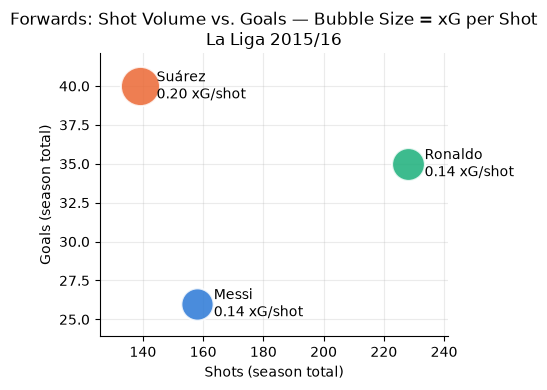

In [ ]:

import matplotlib.pyplot as plt

# fixed player -> color mapping, consistent every time this cell reruns
PLAYER_COLORS = {"Messi": "#2a78d6", "Suárez": "#eb6834", "Ronaldo": "#1baf7a"}

fig, ax = plt.subplots(figsize=(5, 4))

for _, row in forward_shooting.iterrows():
    ax.scatter(
        row["shots"],
        row["goals"],
        s=row["xg_per_shot"] * 4000,  # bubble area encodes shot quality
        color=PLAYER_COLORS[row["player"]],
        alpha=0.85,
        edgecolors="white",
        linewidths=1.5,
        zorder=3,
    )
    ax.annotate(
        f"{row['player']}\n{row['xg_per_shot']:.2f} xG/shot",
        (row["shots"], row["goals"]),
        xytext=(12, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
    )
ax.margins(0.15)
ax.set_xlabel("Shots (season total)")
ax.set_ylabel("Goals (season total)")
ax.set_title("Forwards: Shot Volume vs. Goals — Bubble Size = xG per Shot\nLa Liga 2015/16")
ax.grid(True, alpha=0.25, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
forward_passing = sb_client.get_player_passing_season(
    competition_id=COMPETITION_ID,
    season_ids=SEASON_ID,
    players=FORWARDS,
)
forward_passing["player"] = forward_passing["player"].map(PLAYER_LABELS)

forward_passing.sort_values("passes", ascending=False)

,player,team,season_id,season_name,matches_played,position,passes,passes_completed,completion_rate,progressive_passes,line_breaking_passes
1,Messi,Barcelona,27,2015/2016,33,Right Wing,1926,1544,80.2,512,107
0,Ronaldo,Real Madrid,27,2015/2016,36,Left Wing,1146,878,76.6,170,6
2,Suárez,Barcelona,27,2015/2016,35,Center Forward,973,707,72.7,193,23


In [28]:
forward_goals_assists = sb_client.get_player_goals_assists_season(
    competition_id=COMPETITION_ID,
    season_ids=SEASON_ID,
    players=FORWARDS,
)
forward_goals_assists["player"] = forward_goals_assists["player"].map(PLAYER_LABELS)
forward_goals_assists.sort_values("goals", ascending=False)

,player,team,season_id,season_name,matches_played,position,goals,assists
2,Suárez,Barcelona,27,2015/2016,25,Center Forward,40,15
0,Ronaldo,Real Madrid,27,2015/2016,22,Left Wing,35,10
1,Messi,Barcelona,27,2015/2016,23,Right Wing,26,15


We see all three players have very different passing profiles judging from the amount of line breaking and progressive passes. However, the assist numbers are interestingly similar.  This shows how the different roles of these forward players are clearly represented in data.  Visualizing it can make it even more obvious.  Visualization below

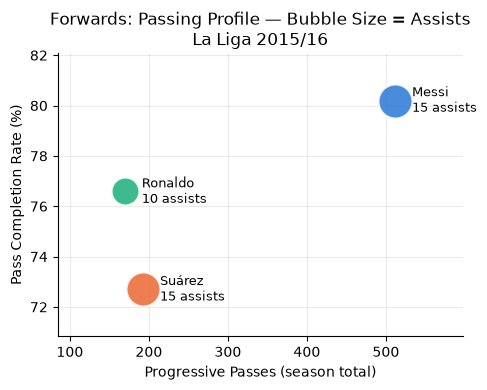

In [30]:
forward_passing_profile = forward_passing.merge(
    forward_goals_assists[["player", "team", "assists"]],
    on=["player", "team"],
)

fig, ax = plt.subplots(figsize=(5, 4))

for _, row in forward_passing_profile.iterrows():
    ax.scatter(
        row["progressive_passes"],
        row["completion_rate"],
        s=row["assists"] * 40,  # bubble area encodes assists
        color=PLAYER_COLORS[row["player"]],
        alpha=0.85,
        edgecolors="white",
        linewidths=1.5,
        zorder=3,
    )
    ax.annotate(
        f"{row['player']}\n{row['assists']} assists",
        (row["progressive_passes"], row["completion_rate"]),
        xytext=(12, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )

ax.margins(0.25)
ax.set_xlabel("Progressive Passes (season total)")
ax.set_ylabel("Pass Completion Rate (%)")
ax.set_title("Forwards: Passing Profile — Bubble Size = Assists\nLa Liga 2015/16")
ax.grid(True, alpha=0.25, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [27]:
midfielder_passing = sb_client.get_player_passing_season(
    competition_id=COMPETITION_ID,
    season_ids=SEASON_ID,
    players=MIDFIELDERS,
)
midfielder_passing["player"] = midfielder_passing["player"].map(PLAYER_LABELS)
midfielder_passing.sort_values("completion_rate", ascending=False)

,player,team,season_id,season_name,matches_played,position,passes,passes_completed,completion_rate,progressive_passes,line_breaking_passes
2,Busquets,Barcelona,27,2015/2016,35,Center Defensive Midfield,2406,2182,90.7,190,17
1,Modrić,Real Madrid,27,2015/2016,32,Right Center Midfield,2270,2026,89.3,349,22
0,Iniesta,Barcelona,27,2015/2016,28,Left Center Midfield,1877,1641,87.4,295,43
